In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [33]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

In [34]:
df.isna()

,TV,Radio,Social_Media,Sales
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
4567,False,False,False,False
4568,False,False,False,False
4569,False,False,False,False
4570,False,False,False,False


In [35]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [36]:
df.shape

(4572, 4)

In [37]:
df.describe

<bound method NDFrame.describe of         TV      Radio  Social_Media       Sales
0     16.0   6.566231      2.907983   54.732757
1     13.0   9.237765      2.409567   46.677897
2     41.0  15.886446      2.913410  150.177829
3     83.0  30.020028      6.922304  298.246340
4     15.0   8.437408      1.405998   56.594181
...    ...        ...           ...         ...
4567  26.0   4.472360      0.717090   94.685866
4568  71.0  20.610685      6.545573  249.101915
4569  44.0  19.800072      5.096192  163.631457
4570  71.0  17.534640      1.940873  253.610411
4571  42.0  15.966688      5.046548  148.202414

[4572 rows x 4 columns]>

In [38]:
df.mean()

TV               54.066857
Radio            18.160356
Social_Media      3.323956
Sales           192.466602
dtype: float64

In [39]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


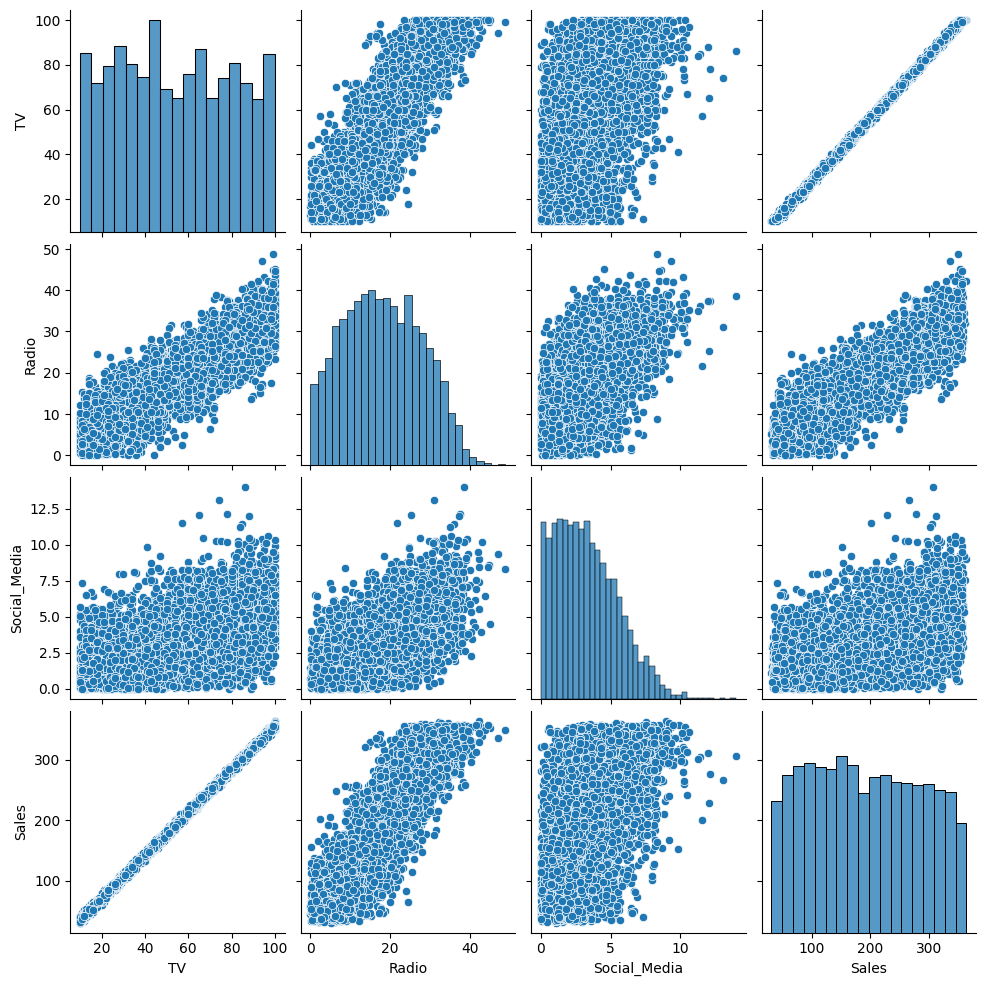

In [59]:
sns.pairplot(data=df)

In [ ]:
df['Sales'].isnull().sum()/len(df['Sales'])*100 #i did this 

np.float64(0.13123359580052493)

In [50]:
df['Sales'].isna().mean() * 100 #chatgpt did this 

np.float64(0.13123359580052493)

In [51]:
round(df['Sales'].isna().mean() * 100, 2) #chatgpt did this as well 

np.float64(0.13)

In [53]:
df = df.dropna(axis=0)

Text(0.5, 1.0, 'Sales Data')

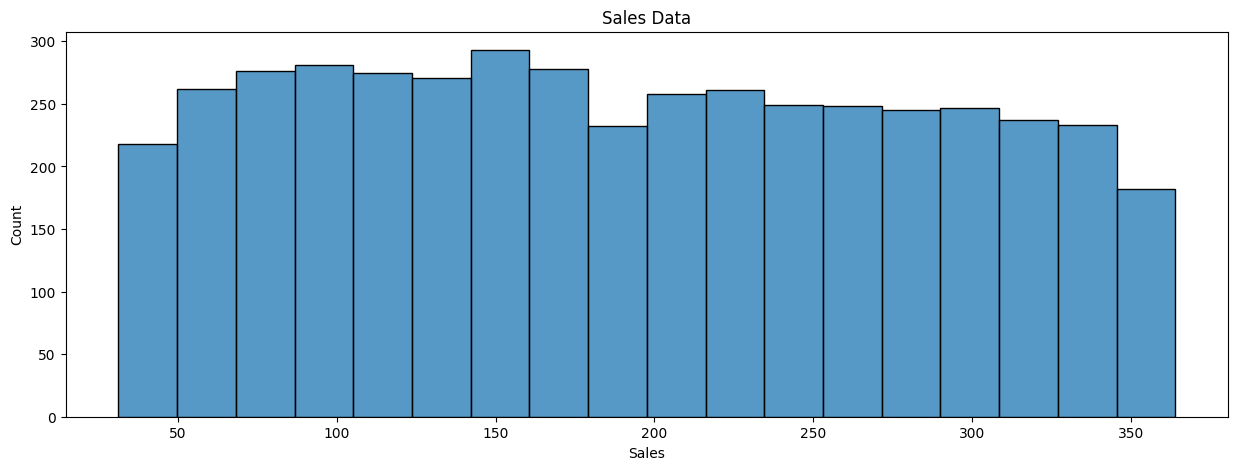

In [58]:
plt.figure(figsize=(15,5))
sns.histplot(data=df, x='Sales')
plt.title('Sales Data')


In [60]:
lin_form = 'Sales ~ TV'
OLS  = ols(formula=lin_form, data = df)
model = OLS.fit()

In [61]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        15:50:23   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='Sales', ylabel='TV'>

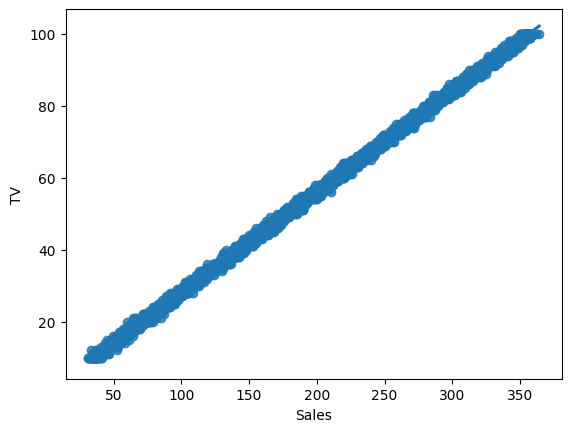

In [63]:
sns.regplot(data=df, x='Sales', y = 'TV')

In [64]:
X = df['TV']
fitted_values = model.predict(X)
residuals = model.resid

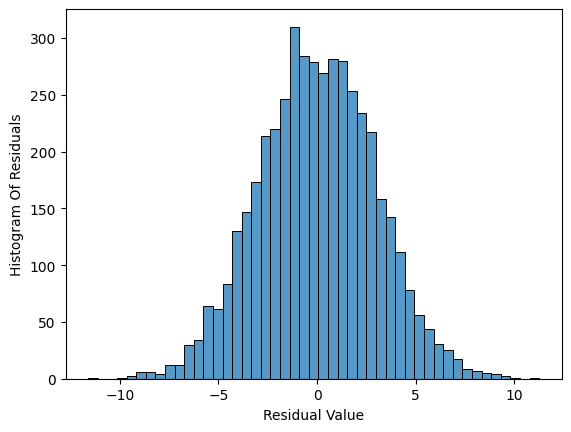

In [65]:
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_ylabel("Histogram Of Residuals")
plt.show()

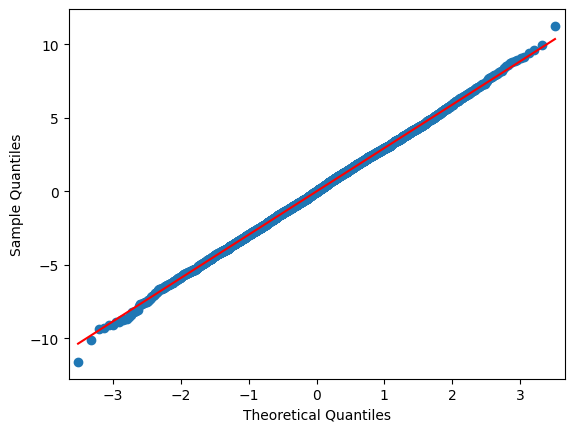

In [66]:
fig = sm.qqplot(model.resid, line= "s")
plt.show()

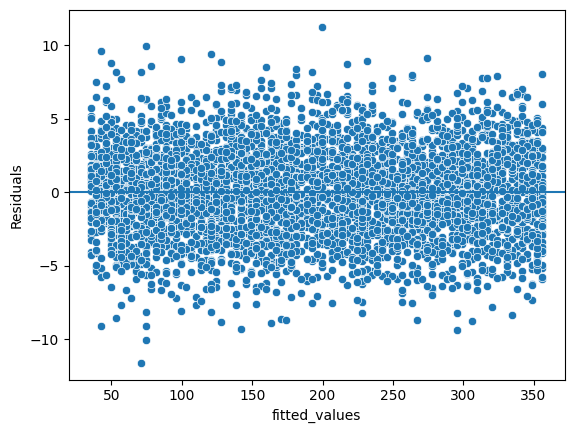

In [67]:
fig  = sns.scatterplot(x = fitted_values, y = residuals)
fig.axhline(0)
fig.set_xlabel("fitted_values")
fig.set_ylabel("Residuals")
plt.show()